<a href="https://colab.research.google.com/github/Ginaitlady/Kaggle/blob/main/RRVF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
import pandas as pd

# 구글 드라이브 마운트
drive.mount('/content/drive')

# 기본 경로 설정
base_path = '/content/drive/MyDrive/Colab Notebooks/'

# CSV 파일 불러오기
air_visit = pd.read_csv(base_path + 'air_visit_data.csv')
air_reserve = pd.read_csv(base_path + 'air_reserve.csv')
hpg_reserve = pd.read_csv(base_path + 'hpg_reserve.csv')
store_id_relation = pd.read_csv(base_path + 'store_id_relation.csv')
air_store_info = pd.read_csv(base_path + 'air_store_info.csv')
hpg_store_info = pd.read_csv(base_path + 'hpg_store_info.csv')
date_info = pd.read_csv(base_path + 'date_info.csv')
sample_submission = pd.read_csv(base_path + 'sample_submission.csv')

# 불러온 데이터 확인 (선택사항)
print("air_visit:", air_visit.shape)
print("air_reserve:", air_reserve.shape)
print("hpg_reserve:", hpg_reserve.shape)
print("store_id_relation:", store_id_relation.shape)
print("air_store_info:", air_store_info.shape)
print("hpg_store_info:", hpg_store_info.shape)
print("date_info:", date_info.shape)
print("sample_submission:", sample_submission.shape)

Mounted at /content/drive
air_visit: (252108, 3)
air_reserve: (92378, 4)
hpg_reserve: (2000320, 4)
store_id_relation: (150, 2)
air_store_info: (829, 5)
hpg_store_info: (4690, 5)
date_info: (517, 3)
sample_submission: (32019, 2)


In [19]:
# 각 데이터프레임의 앞 5줄 확인
print("=== air_visit_data 과거 방문자 수===")
display(air_visit.head())

print("=== air_reserve 예약 시스템의 예약정보===")
display(air_reserve.head())

print("=== hpg_reserve ===")
display(hpg_reserve.head())

print("=== store_id_relation air와 hpg시스템간 매핑===")
display(store_id_relation.head())

print("=== air_store_info 레스토랑 위치 ===")
display(air_store_info.head())

print("=== hpg_store_info 레스토랑 장르===")
display(hpg_store_info.head())

print("=== date_info 날짜별 요일, 휴일 여부등 캘린더 정보===")
display(date_info.head())

print("=== sample_submission ===")
display(sample_submission.head())

# date_info.head(20)

=== air_visit_data 과거 방문자 수===


,air_store_id,visit_date,visitors,day_of_week,year,month
0,air_ba937bf13d40fb24,2016-01-13,25,2,2016,1
1,air_ba937bf13d40fb24,2016-01-14,32,3,2016,1
2,air_ba937bf13d40fb24,2016-01-15,29,4,2016,1
3,air_ba937bf13d40fb24,2016-01-16,22,5,2016,1
4,air_ba937bf13d40fb24,2016-01-18,6,0,2016,1


=== air_reserve 예약 시스템의 예약정보===


,air_store_id,visit_datetime,reserve_datetime,reserve_visitors
0,air_877f79706adbfb06,2016-01-01 19:00:00,2016-01-01 16:00:00,1
1,air_db4b38ebe7a7ceff,2016-01-01 19:00:00,2016-01-01 19:00:00,3
2,air_db4b38ebe7a7ceff,2016-01-01 19:00:00,2016-01-01 19:00:00,6
3,air_877f79706adbfb06,2016-01-01 20:00:00,2016-01-01 16:00:00,2
4,air_db80363d35f10926,2016-01-01 20:00:00,2016-01-01 01:00:00,5


=== hpg_reserve ===


...

=== date_info 날짜별 요일, 휴일 여부등 캘린더 정보===


,calendar_date,day_of_week,holiday_flg
0,2016-01-01,Friday,1
1,2016-01-02,Saturday,1
2,2016-01-03,Sunday,1
3,2016-01-04,Monday,0
4,2016-01-05,Tuesday,0


=== sample_submission ===


,id,visitors,air_store_id,visit_date,day_of_week,year,month
0,air_00a91d42b08b08d9_2017-04-23,0,air_00a91d42b08b08d9,2017-04-23,6,2017,4
1,air_00a91d42b08b08d9_2017-04-24,0,air_00a91d42b08b08d9,2017-04-24,0,2017,4
2,air_00a91d42b08b08d9_2017-04-25,0,air_00a91d42b08b08d9,2017-04-25,1,2017,4
3,air_00a91d42b08b08d9_2017-04-26,0,air_00a91d42b08b08d9,2017-04-26,2,2017,4
4,air_00a91d42b08b08d9_2017-04-27,0,air_00a91d42b08b08d9,2017-04-27,3,2017,4


,calendar_date,day_of_week,holiday_flg
0,2016-01-01,Friday,1
1,2016-01-02,Saturday,1
2,2016-01-03,Sunday,1
3,2016-01-04,Monday,0
4,2016-01-05,Tuesday,0
5,2016-01-06,Wednesday,0
6,2016-01-07,Thursday,0
7,2016-01-08,Friday,0
8,2016-01-09,Saturday,0
9,2016-01-10,Sunday,0


In [5]:
# 날짜 처리
air_visit['visit_date'] = pd.to_datetime(air_visit['visit_date'])
air_visit['day_of_week'] = air_visit['visit_date'].dt.dayofweek
air_visit['year'] = air_visit['visit_date'].dt.year
air_visit['month'] = air_visit['visit_date'].dt.month

# 요일별 평균 방문자 수 파생 변수
dow_mean = air_visit.groupby(['air_store_id', 'day_of_week'])['visitors'].mean().reset_index()
dow_mean.columns = ['air_store_id', 'day_of_week', 'dow_visitors_mean']

# sample_submission에서 store_id, 날짜 분리
sample_submission['air_store_id'] = sample_submission['id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
sample_submission['visit_date'] = sample_submission['id'].apply(lambda x: x.split('_')[-1])
sample_submission['visit_date'] = pd.to_datetime(sample_submission['visit_date'])
sample_submission['day_of_week'] = sample_submission['visit_date'].dt.dayofweek
sample_submission['year'] = sample_submission['visit_date'].dt.year
sample_submission['month'] = sample_submission['visit_date'].dt.month

# 학습/예측용 데이터 통합
train = air_visit.copy()
test = sample_submission.copy()

# 요일별 평균 병합
train = pd.merge(train, dow_mean, on=['air_store_id', 'day_of_week'], how='left')
test = pd.merge(test, dow_mean, on=['air_store_id', 'day_of_week'], how='left')

# 결측값 처리
test['dow_visitors_mean'] = test['dow_visitors_mean'].fillna(train['visitors'].mean())


In [22]:
print(air_visit.head())
print(sample_submission.head())

           air_store_id visit_date  visitors  day_of_week  year  month
0  air_ba937bf13d40fb24 2016-01-13        25            2  2016      1
1  air_ba937bf13d40fb24 2016-01-14        32            3  2016      1
2  air_ba937bf13d40fb24 2016-01-15        29            4  2016      1
3  air_ba937bf13d40fb24 2016-01-16        22            5  2016      1
4  air_ba937bf13d40fb24 2016-01-18         6            0  2016      1
                                id  visitors          air_store_id visit_date  \
0  air_00a91d42b08b08d9_2017-04-23         0  air_00a91d42b08b08d9 2017-04-23   
1  air_00a91d42b08b08d9_2017-04-24         0  air_00a91d42b08b08d9 2017-04-24   
2  air_00a91d42b08b08d9_2017-04-25         0  air_00a91d42b08b08d9 2017-04-25   
3  air_00a91d42b08b08d9_2017-04-26         0  air_00a91d42b08b08d9 2017-04-26   
4  air_00a91d42b08b08d9_2017-04-27         0  air_00a91d42b08b08d9 2017-04-27   

   day_of_week  year  month  
0            6  2017      4  
1            0  2017      4

In [6]:
!pip install lightgbm --quiet

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import numpy as np

# 학습용 피처
features = ['day_of_week', 'year', 'month', 'dow_visitors_mean']

X = train[features]
y = train['visitors']
X_test = test[features]

# 로그 변환
y_log = np.log1p(y)

# 모델 훈련
model = LGBMRegressor(random_state=42)
model.fit(X, y_log)

# 예측 및 역로그 변환
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 278
[LightGBM] [Info] Number of data points in the train set: 252108, number of used features: 4
[LightGBM] [Info] Start training from score 2.802788


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


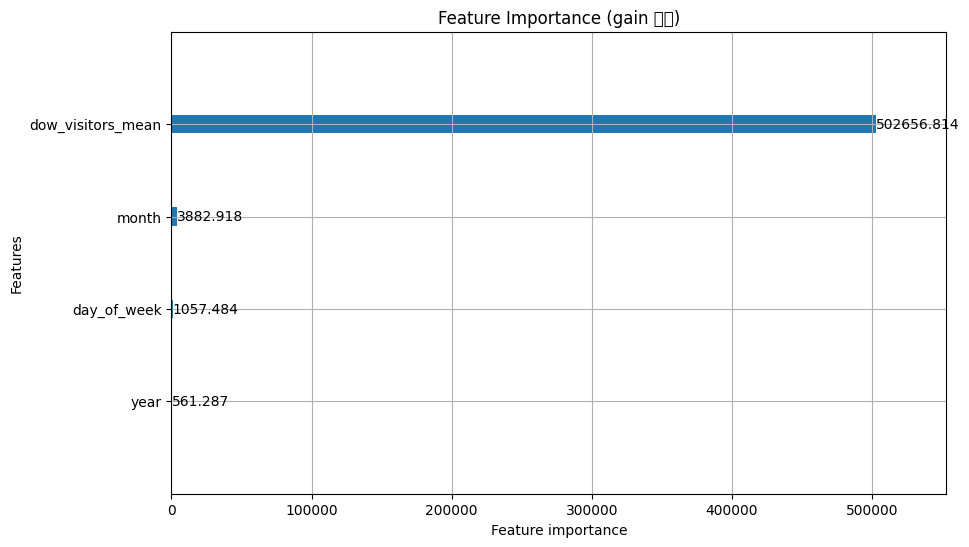

In [8]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# 특성 중요도 시각화
lgb.plot_importance(model, max_num_features=10, importance_type='gain', figsize=(10, 6))
plt.title("Feature Importance (gain 기준)")
plt.show()


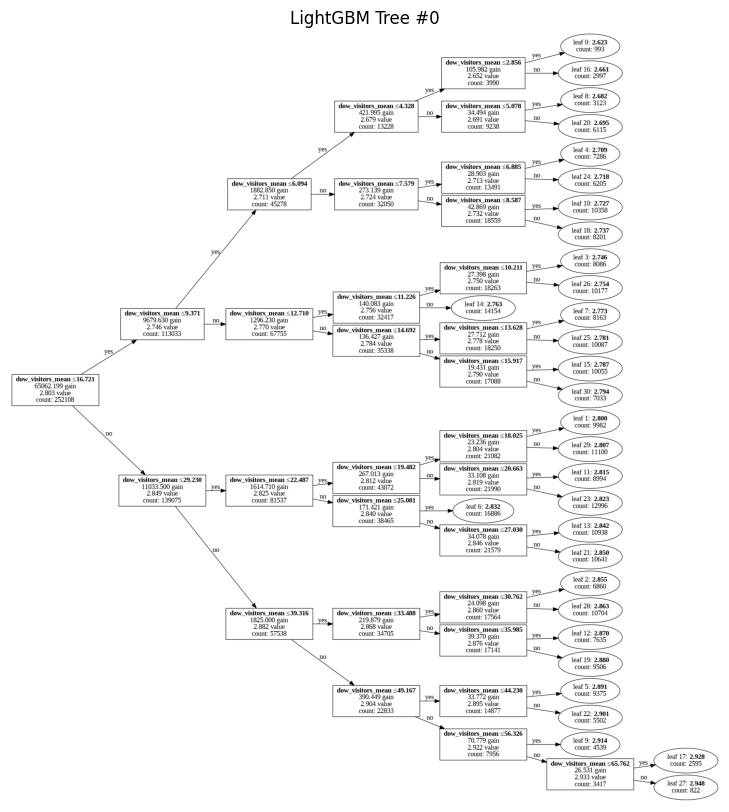

In [9]:
lgb.plot_tree(model, tree_index=0, figsize=(20, 10), show_info=['split_gain', 'internal_value', 'internal_count', 'leaf_count'])
plt.title("LightGBM Tree #0")
plt.show()


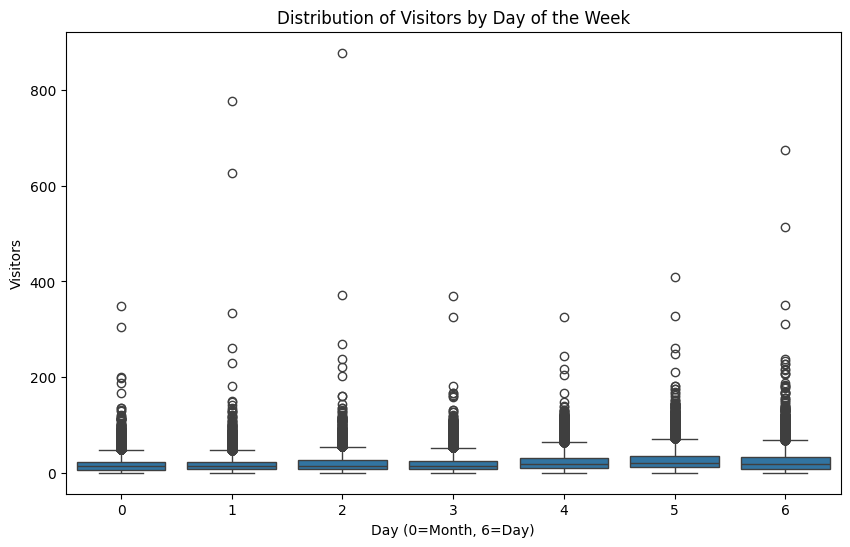

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 시계열 시각화 예제 (트렌드, 요일, 이벤트)

# 방문자 수와 요일 관계
train['visit_date'] = pd.to_datetime(train['visit_date'])
train['day_of_week'] = train['visit_date'].dt.dayofweek

plt.figure(figsize=(10,6))
sns.boxplot(data=train, x='day_of_week', y='visitors')
plt.title('Distribution of Visitors by Day of the Week')
plt.xlabel('Day (0=Month, 6=Day)')
plt.ylabel('Visitors')
plt.show()

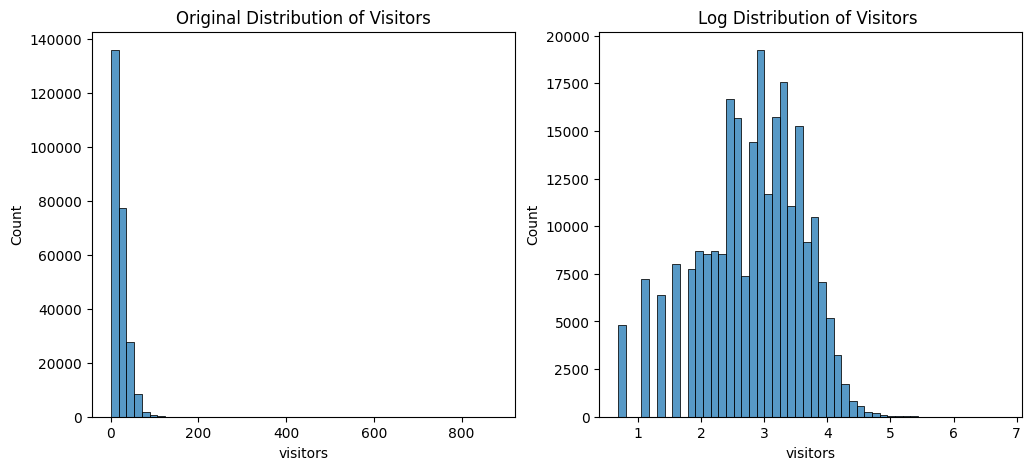

In [15]:
#  타겟 변수 visitors의 안정성 체크
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(train['visitors'], bins=50)
plt.title('Original Distribution of Visitors')

plt.subplot(1,2,2)
sns.histplot(np.log1p(train['visitors']), bins=50)
plt.title('Log Distribution of Visitors ')
plt.show()

In [ ]:
# 이상치 제거
train = train[train['visitors'] < 100]  # 방문자 수 100 이상은 제거

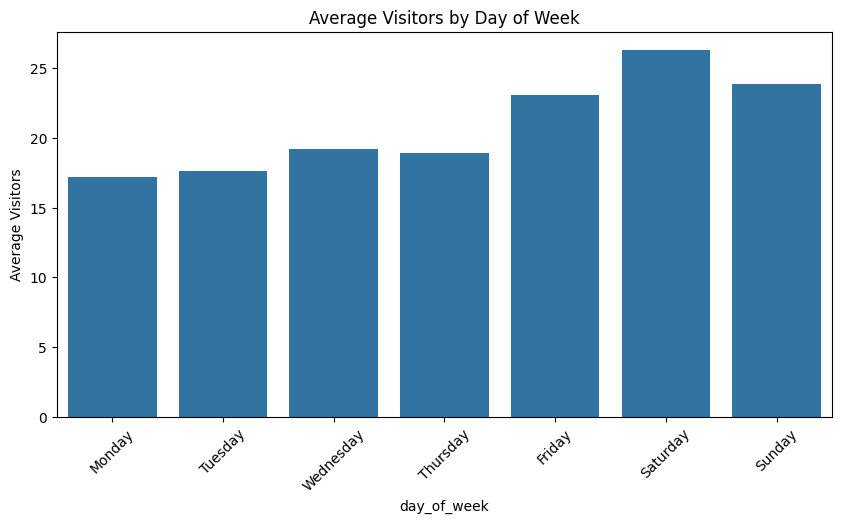

In [23]:
#  요일별 평균 방문자 수
air_visit['visit_date'] = pd.to_datetime(air_visit['visit_date'])
air_visit['day_of_week'] = air_visit['visit_date'].dt.day_name()

# 요일별 평균
dow_visitors = air_visit.groupby('day_of_week')['visitors'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

# 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(x=dow_visitors.index, y=dow_visitors.values)
plt.title("Average Visitors by Day of Week")
plt.ylabel("Average Visitors")
plt.xticks(rotation=45)
plt.show()


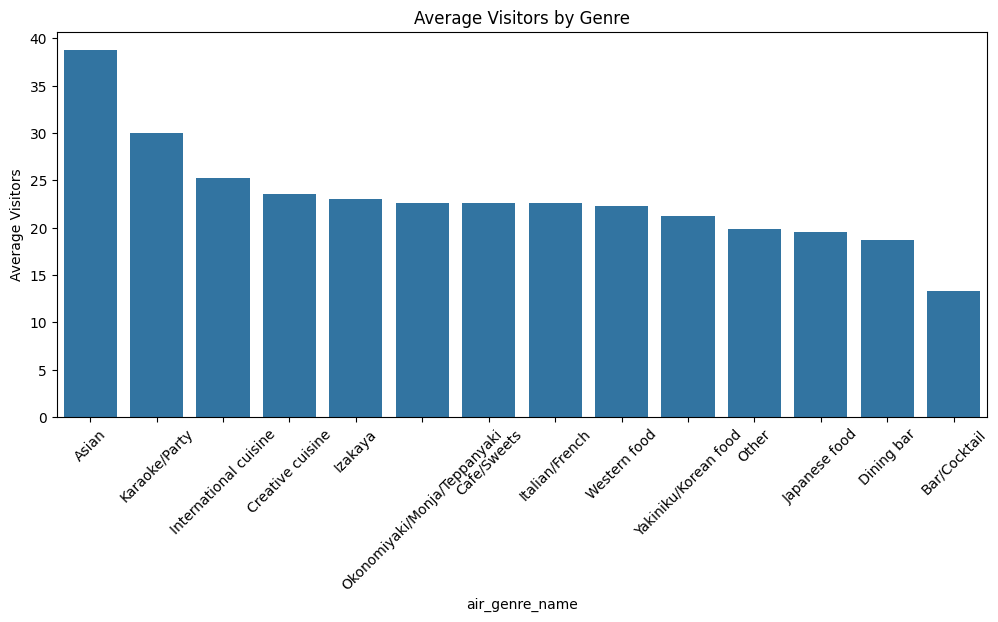

In [25]:
# air_visit와 air_store_info 병합
merged = pd.merge(air_visit, air_store_info, on='air_store_id')

# 장르별 평균 방문자 수 계산
genre_visitors = merged.groupby('air_genre_name')['visitors'].mean().sort_values(ascending=False)

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_visitors.index, y=genre_visitors.values)
plt.title("Average Visitors by Genre")
plt.ylabel("Average Visitors")
plt.xticks(rotation=45)
plt.show()


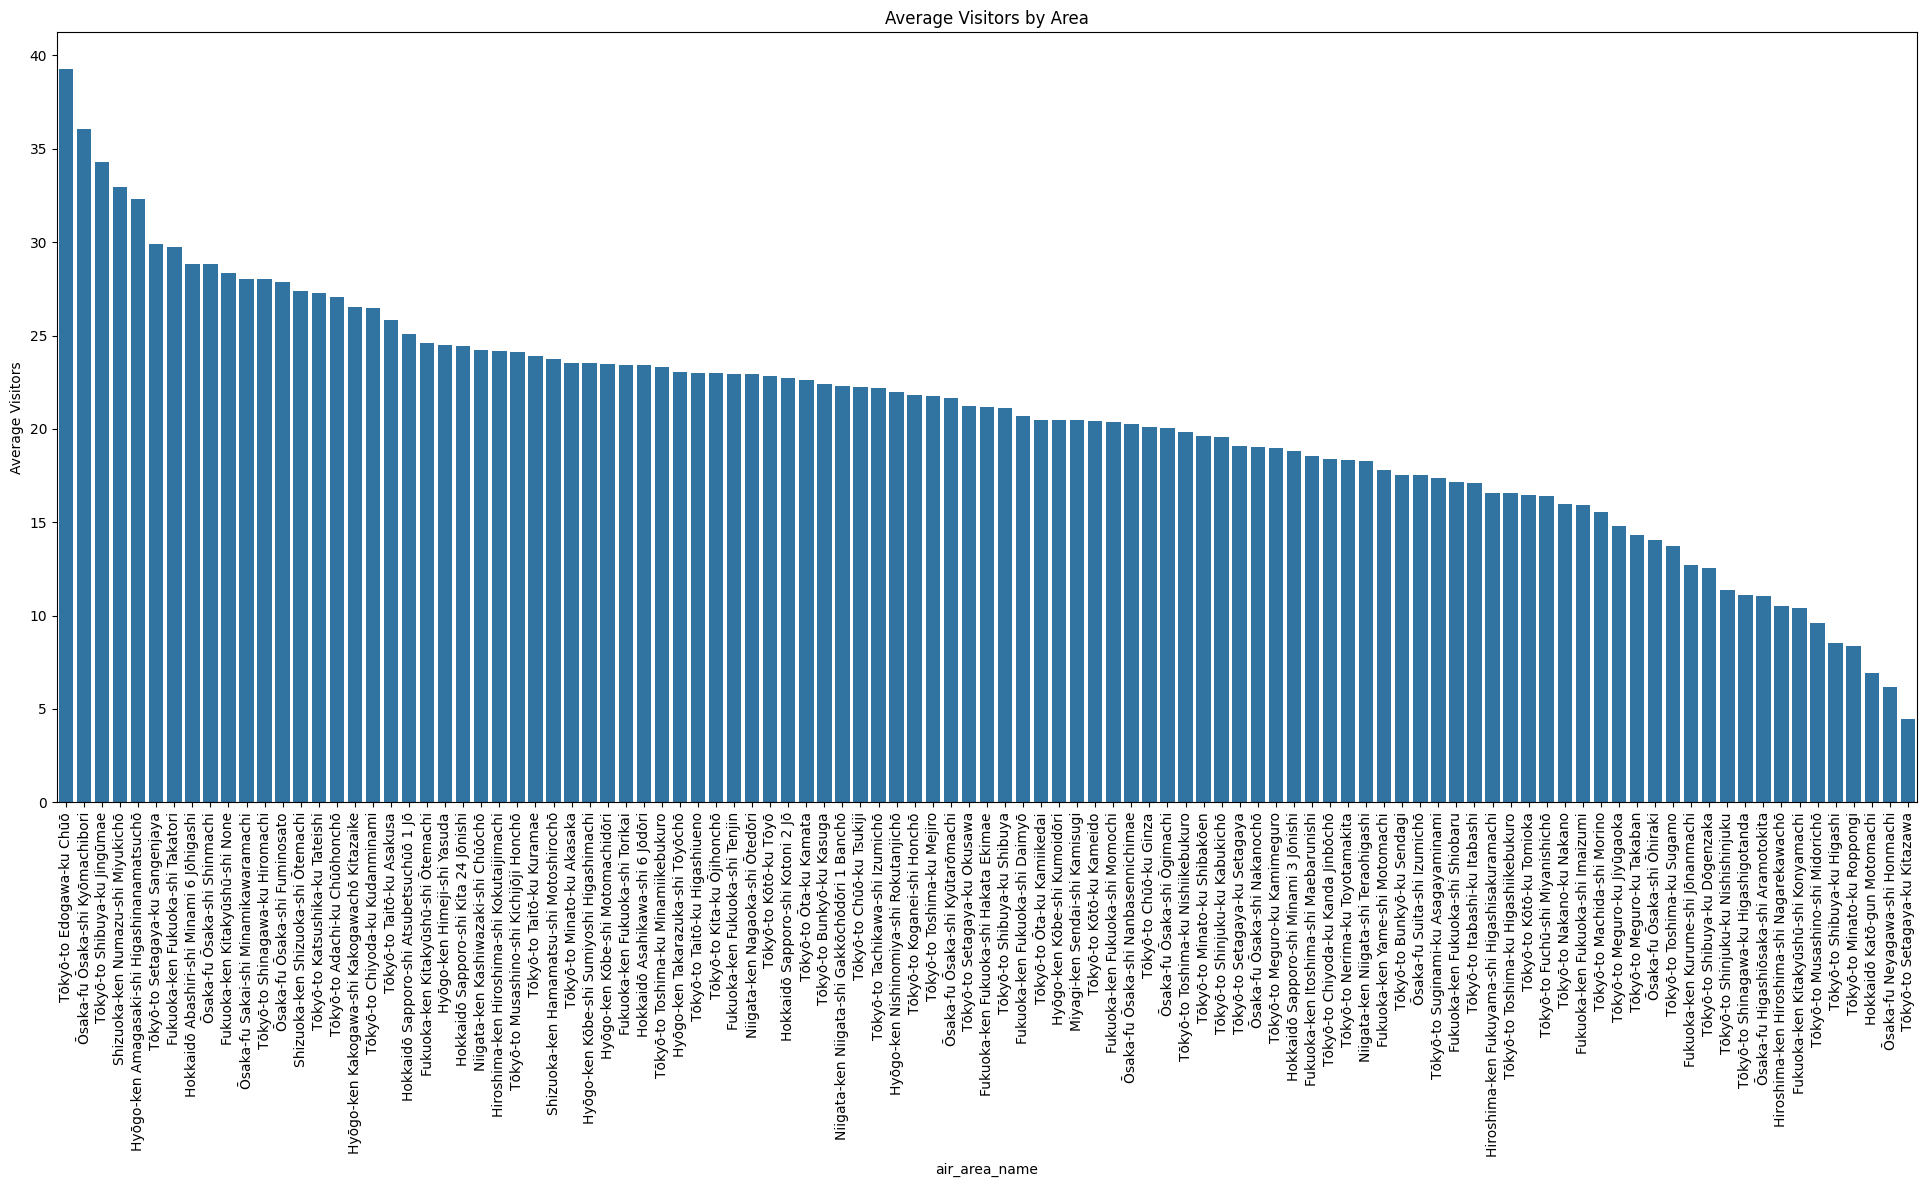

In [28]:
#  지역별 평균 방문자 수
# 'air_area_name' 컬럼으로 수정
area_visitors = merged.groupby('air_area_name')['visitors'].mean().sort_values(ascending=False)

# 시각화
plt.figure(figsize=(24, 10))
sns.barplot(x=area_visitors.index, y=area_visitors.values)
plt.title("Average Visitors by Area")
plt.ylabel("Average Visitors")
plt.xticks(rotation=90)
plt.show()



In [31]:
# 예약 인원 총합, 평균 예약 시간 차이

# 날짜 컬럼 변환
air_reserve['visit_datetime'] = pd.to_datetime(air_reserve['visit_datetime'])
air_reserve['reserve_datetime'] = pd.to_datetime(air_reserve['reserve_datetime'])

# 예약 시간 차이 계산 (단위: 시간)
air_reserve['reserve_diff'] = (air_reserve['visit_datetime'] - air_reserve['reserve_datetime']).dt.total_seconds() / 3600

# 가게별 예약 총합/평균 계산
reserve_stats = air_reserve.groupby('air_store_id').agg({
    'reserve_visitors': ['sum', 'mean'],
    'reserve_diff': 'mean'
}).reset_index()

# 컬럼명 정리
reserve_stats.columns = ['air_store_id', 'total_reserve_visitors', 'mean_reserve_visitors', 'mean_reserve_diff']

# 출력 확인
reserve_stats.head(10)


,air_store_id,total_reserve_visitors,mean_reserve_visitors,mean_reserve_diff
0,air_00a91d42b08b08d9,70,5.833333,94.083333
1,air_0164b9927d20bcc3,517,3.379085,211.032680
2,air_034a3d5b40d5b1b1,93,6.642857,167.785714
3,air_03963426c9312048,8200,6.471981,181.683504
4,air_04341b588bde96cd,208,17.333333,290.000000
5,air_04cae7c1bc9b2a0b,2515,3.608321,107.064562
6,air_066f0221b8a4d533,516,5.319588,137.360825
7,air_06f95ac5c33aca10,31,7.750000,211.250000
8,air_082908692355165e,276,4.758621,55.034483
9,air_084d98859256acf0,8,4.000000,1.500000


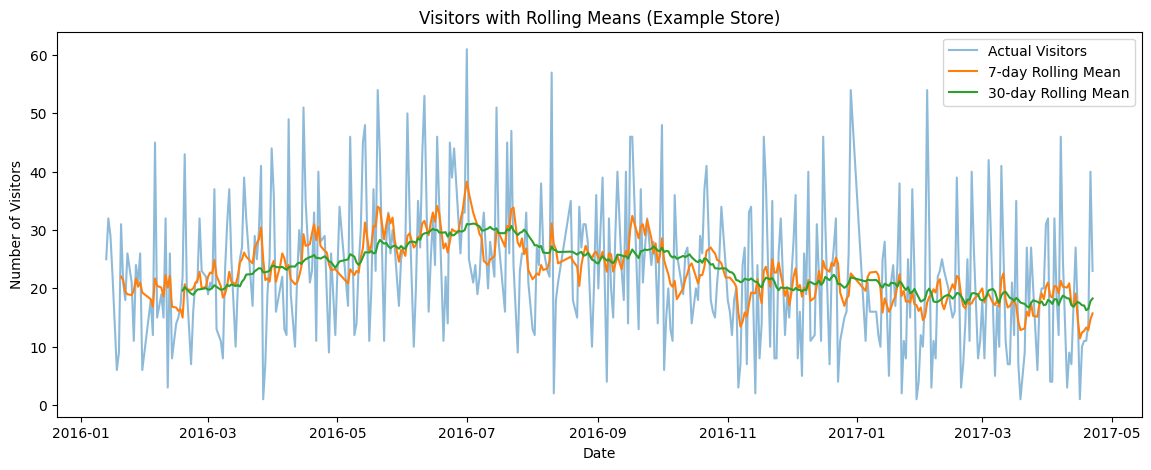

In [32]:
# 최근 7일, 30일 평균 방문자 수

# 날짜 형식 변환
air_visit['visit_date'] = pd.to_datetime(air_visit['visit_date'])

# 정렬 후 rolling 계산
rolling = air_visit.sort_values(['air_store_id', 'visit_date']).copy()
rolling['rolling_7'] = rolling.groupby('air_store_id')['visitors'].transform(lambda x: x.rolling(7).mean())
rolling['rolling_30'] = rolling.groupby('air_store_id')['visitors'].transform(lambda x: x.rolling(30).mean())

# 예시 가게 하나 선택해서 시각화
example_store = 'air_ba937bf13d40fb24'
store = rolling[rolling['air_store_id'] == example_store]

plt.figure(figsize=(14, 5))
plt.plot(store['visit_date'], store['visitors'], label='Actual Visitors', alpha=0.5)
plt.plot(store['visit_date'], store['rolling_7'], label='7-day Rolling Mean')
plt.plot(store['visit_date'], store['rolling_30'], label='30-day Rolling Mean')
plt.legend()
plt.title("Visitors with Rolling Means (Example Store)")
plt.xlabel("Date")
plt.ylabel("Number of Visitors")
plt.show()


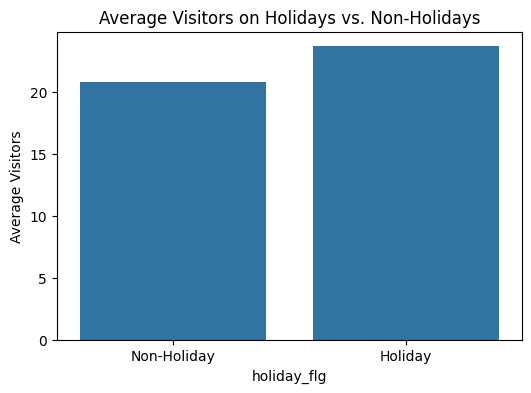

In [33]:
# 공휴일 여부, 분기등의 datetime 파생 변수

# 날짜 변환
air_visit['visit_date'] = pd.to_datetime(air_visit['visit_date'])

# 파생 변수 생성
air_visit['month'] = air_visit['visit_date'].dt.month
air_visit['quarter'] = air_visit['visit_date'].dt.quarter
air_visit['year'] = air_visit['visit_date'].dt.year

# 공휴일 정보 병합
date_info['calendar_date'] = pd.to_datetime(date_info['calendar_date'])
air_visit = pd.merge(air_visit, date_info[['calendar_date', 'holiday_flg']],
                     left_on='visit_date', right_on='calendar_date', how='left')

# 공휴일별 평균 방문자 수 계산
holiday_visitors = air_visit.groupby('holiday_flg')['visitors'].mean()

# 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=holiday_visitors.index, y=holiday_visitors.values)
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
plt.title("Average Visitors on Holidays vs. Non-Holidays")
plt.ylabel("Average Visitors")
plt.show()